### Preparazione del dataset

Parto dal dataset ridotto dal mitico Trio, 34 variabili totali, escluse quelle che non hanno superato il chi quadro test e Mann-Whitney test e quelle dal test VIF sulla multicolinearità

In [ ]:
import pandas as pd

df=pd.read_csv("C:/Users/Utente/Desktop/LUCA/università/DATA_SCIENCE/1_ANNO/cleaned_df2.csv")
target = 'cyber_fraud_victim'


##############################
# Variabili espluse 
##############################

vars_to_excludee = [
    target, 
    'wght', 
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean',
    # --- NUOVE AGGIUNTE DAL TEST VIF ---
    'subj_knowledge_label', # Clone categorico di qk1_clean
    'use_own_resources',    # Sovrapposta a income_not_covering_costs
    'age_group'             # Crea rumore ed è assorbita dai digital scores
]

#################
# stampo le variabili che rimangono
#################

variabili_tenute=[col for col in df.columns if col not in vars_to_excludee]


#############
# Variabili categoriche NON ORDINABILI 
#############
var_cat_non_o = [
    "gender", "household_budget_decisions", "expenditure_shock_capacity", 
    "income_not_covering_costs", "private_pension_asset", "informal_network_pension", 
    "informal_external_help", "use_dangerous_debt", "institutional_friction",
    "credit_excluded", "qk3_clean", "qk6_clean", "qk10_clean", "living_status"
]

#############
# Variabili categoriche ORDINABILI 
#############
var_cat_o = [
    "retirement_plan_confidence", "lost_income_survival_time", "saving_level_sophistication", 
    "risk_aversion_class", "daily_transactional_intensity", "basic_admin_intensity", 
    "qk1_clean", "qk7_clean", "household_size", "edu_level_grouped", 
    "income_label", "advanced_fintech_intensity"
]

#############
# Variabili continue 
#############
var_con = [
    "financial_planning_score", "saving_protection_score", "alternative_asset_score",
    "digital_onboarding_score", "obj_score", "finacial_situation", 
    "knowledge_financial_privacy_digital", "digital_skills_score"
]


In [3]:
df=df[variabili_tenute +[target]]
df.head()

,gender,household_budget_decisions,expenditure_shock_capacity,retirement_plan_confidence,income_not_covering_costs,lost_income_survival_time,financial_planning_score,saving_level_sophistication,private_pension_asset,informal_network_pension,...,qk7_clean,obj_score,finacial_situation,knowledge_financial_privacy_digital,living_status,household_size,digital_skills_score,edu_level_grouped,income_label,cyber_fraud_victim
0,Man,you,yes_immediate,very_confident,no,6_months_or_more,4,1.0,1,0,...,6,100.000000,32.0,47.0,Alone,1.0,2.714286,High School,1751-2900€,0
1,Man,you and someone else,NaN,not_confident,NaN,NaN,1,NaN,0,1,...,0,16.666667,12.0,32.0,With_Children,9.0,3.285714,High School,Unknown,0
2,Woman,someone else,NaN,middle,NaN,1_week_to_1_month,0,2.0,0,0,...,1,19.444444,30.0,30.0,With_Partner,3.0,2.428571,High School,Unknown,0
3,Woman,NaN,NaN,NaN,yes,NaN,3,0.0,1,1,...,0,33.333333,17.0,35.0,Other,4.0,3.000000,University,Unknown,0
4,Man,you and someone else,NaN,not_confident_at_all,no,less_than_a_week,1,0.0,0,0,...,2,55.555556,16.0,38.0,With_Partner,3.0,2.142857,Middle School,<=1750€,0


### Confronto tra SVM, XGBoost e NaiveBayes

Dataset: 4862 righe, 34 features
Distribuzione target:
cyber_fraud_victim
0    4404
1     458
Name: count, dtype: int64

Feature matrix shape dopo encoding: (4862, 43)
Train: 3889 righe | Test: 973 righe
Dopo SMOTE → {1: 3523, 0: 3523}

  SVM (RBF)  (threshold = 0.5)
                  precision    recall  f1-score   support

Non truffato (0)       0.94      0.96      0.95       881
    Truffato (1)       0.49      0.38      0.43        92

        accuracy                           0.90       973
       macro avg       0.71      0.67      0.69       973
    weighted avg       0.89      0.90      0.90       973

  Naive Bayes  (threshold = 0.5)
                  precision    recall  f1-score   support

Non truffato (0)       0.95      0.91      0.93       881
    Truffato (1)       0.37      0.53      0.44        92

        accuracy                           0.87       973
       macro avg       0.66      0.72      0.68       973
    weighted avg       0.89      0.87      0.88       97

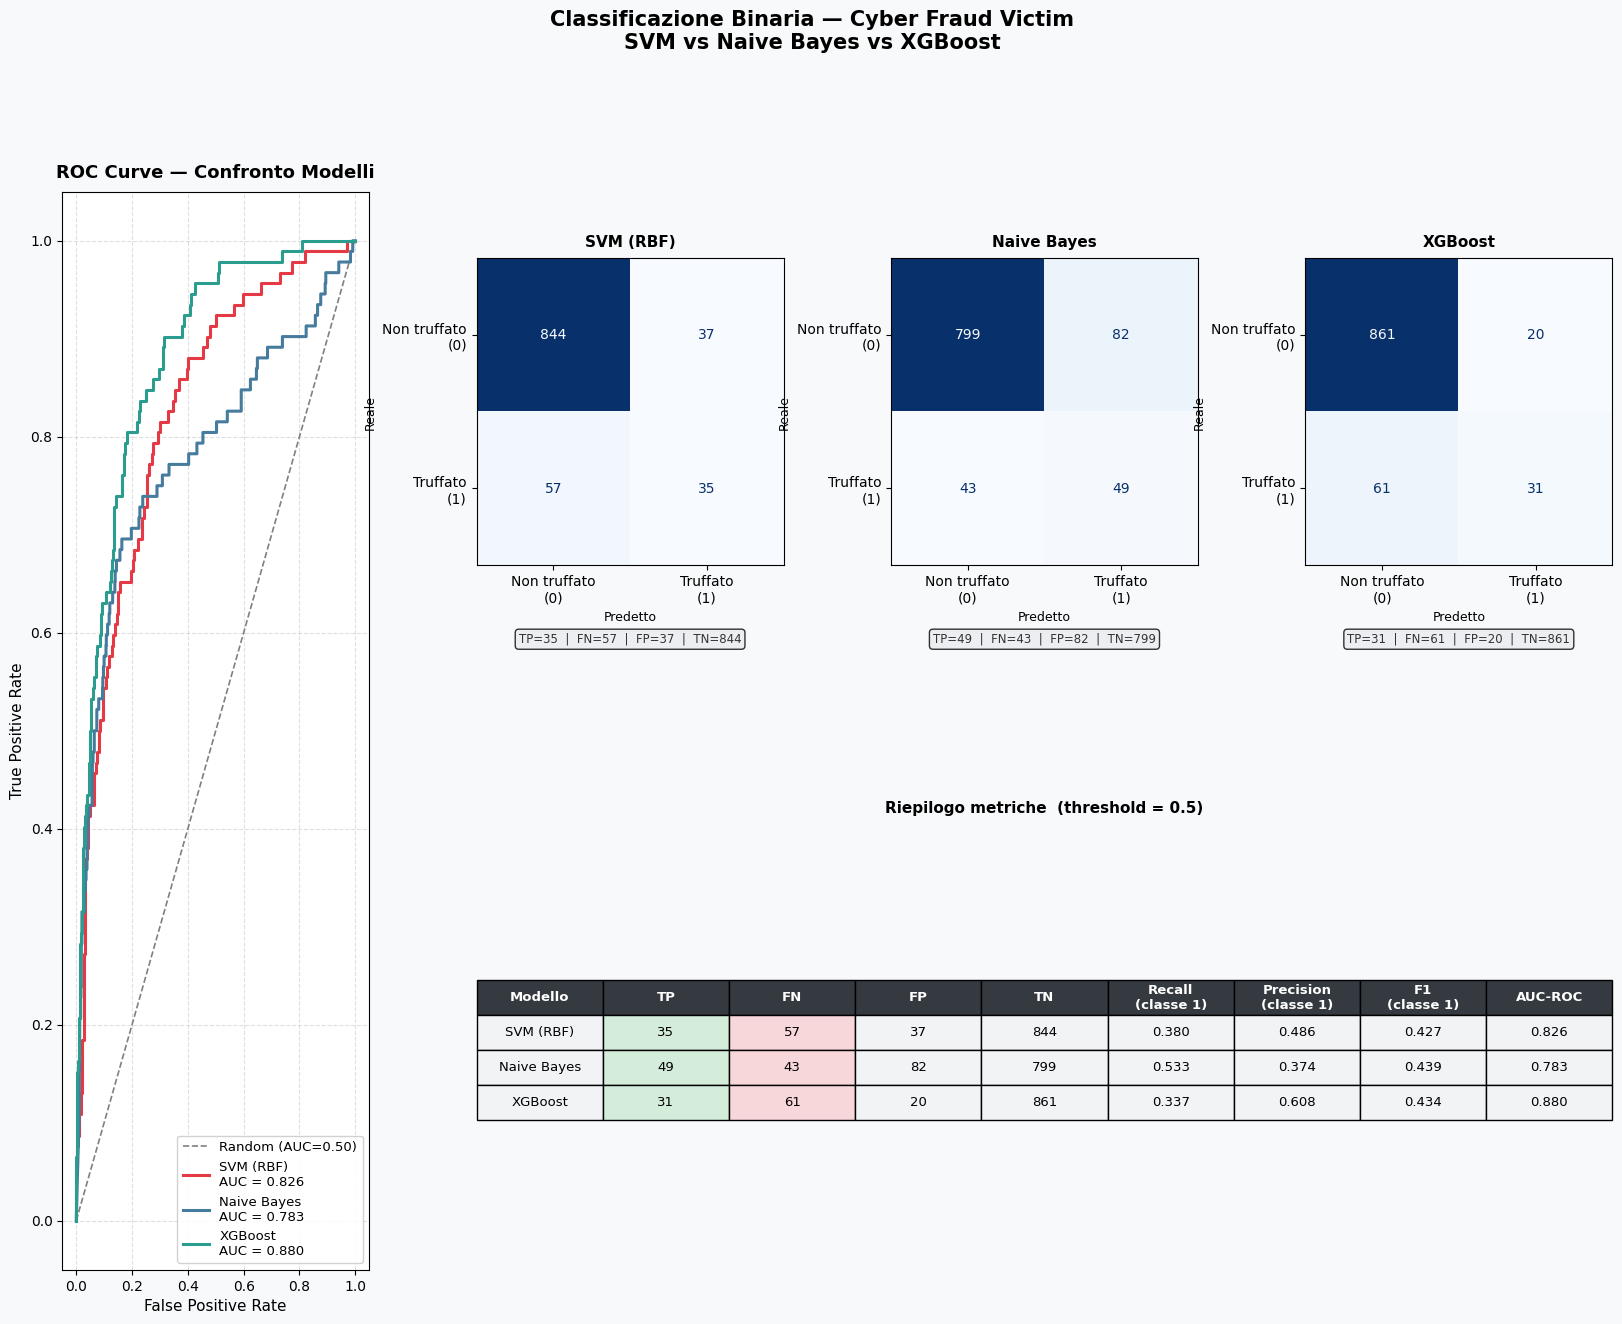


Grafico salvato come 'classification_results.png'


In [4]:
# =============================================================================
# CLASSIFICAZIONE BINARIA - cyber_fraud_victim
# Modelli: SVM, Naive Bayes, XGBoost
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    classification_report
)

# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIGURAZIONE
# ─────────────────────────────────────────────────────────────────────────────
THRESHOLD = 0.5          # <-- abbassa qui per aumentare recall sulla classe 1
RANDOM_STATE = 42
TEST_SIZE = 0.20

# ─────────────────────────────────────────────────────────────────────────────
# 1.  CARICA DATASET
# ─────────────────────────────────────────────────────────────────────────────
# df

# Rimuovi colonne spurie (indice duplicato e target duplicato)
drop_cols = ['Unnamed: 0', 'cyber_fraud_victim.1']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

target = 'cyber_fraud_victim'

# ─────────────────────────────────────────────────────────────────────────────
# 2.  DEFINIZIONE VARIABILI (dal tuo codice)
# ─────────────────────────────────────────────────────────────────────────────
var_cat_non_o = [
    "gender", "household_budget_decisions", "expenditure_shock_capacity",
    "income_not_covering_costs", "private_pension_asset", "informal_network_pension",
    "informal_external_help", "use_dangerous_debt", "institutional_friction",
    "credit_excluded", "qk3_clean", "qk6_clean", "qk10_clean", "living_status"
]

var_cat_o = [
    "retirement_plan_confidence", "lost_income_survival_time", "saving_level_sophistication",
    "risk_aversion_class", "daily_transactional_intensity", "basic_admin_intensity",
    "qk1_clean", "qk7_clean", "household_size", "edu_level_grouped",
    "income_label", "advanced_fintech_intensity"
]

var_con = [
    "financial_planning_score", "saving_protection_score", "alternative_asset_score",
    "digital_onboarding_score", "obj_score", "finacial_situation",
    "knowledge_financial_privacy_digital", "digital_skills_score"
]

# Filtra solo le variabili presenti nel dataset
var_cat_non_o = [c for c in var_cat_non_o if c in df.columns]
var_cat_o     = [c for c in var_cat_o     if c in df.columns]
var_con       = [c for c in var_con       if c in df.columns]

features = var_cat_non_o + var_cat_o + var_con
X_raw = df[features].copy()
y     = df[target].copy()

print(f"Dataset: {df.shape[0]} righe, {len(features)} features")
print(f"Distribuzione target:\n{y.value_counts()}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  ENCODING
# ─────────────────────────────────────────────────────────────────────────────

# --- 3a. Categoriche NON ordinabili → One-Hot Encoding ---
# Le variabili binarie già 0/1 (int) le lasciamo stare;
# le string le codifichiamo
str_non_o = [c for c in var_cat_non_o if X_raw[c].dtype == object]
int_non_o = [c for c in var_cat_non_o if X_raw[c].dtype != object]

X_ohe = pd.get_dummies(X_raw[str_non_o], drop_first=True, dummy_na=True)

# --- 3b. Categoriche ORDINABILI → Ordinal Encoding ---
# Ordini definiti dove rilevante, altrimenti auto
ordinal_orders = {
    "retirement_plan_confidence": [
        "not_confident_at_all", "not_confident", "middle", "confident",
        "very_confident", "no_retirement_plan"
    ],
    "lost_income_survival_time": [
        "less_than_a_week", "1_week_to_1_month", "1_to_3_months",
        "3_to_6_months", "6_months_or_more"
    ],
    "edu_level_grouped": [
        "No Education", "Primary", "Middle School", "High School",
        "University"
    ],
    "income_label": ["<=1750€", "1751-2900€", ">2900€", "Unknown"],
}

str_o = [c for c in var_cat_o if X_raw[c].dtype == object]
int_o = [c for c in var_cat_o if X_raw[c].dtype != object]

X_ord_parts = []
for col in str_o:
    if col in ordinal_orders:
        cats = ordinal_orders[col]
    else:
        cats = sorted(X_raw[col].dropna().unique().tolist())
    enc = OrdinalEncoder(
        categories=[cats],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )
    vals = enc.fit_transform(X_raw[[col]])
    X_ord_parts.append(pd.DataFrame(vals, columns=[col], index=X_raw.index))

X_ord = pd.concat(X_ord_parts, axis=1) if X_ord_parts else pd.DataFrame(index=X_raw.index)

# --- 3c. Assembla feature matrix ---
X = pd.concat(
    [X_ohe,
     X_ord,
     X_raw[int_non_o].reset_index(drop=False).set_index('index') if int_non_o else pd.DataFrame(index=X_raw.index),
     X_raw[int_o].reset_index(drop=False).set_index('index')     if int_o     else pd.DataFrame(index=X_raw.index),
     X_raw[var_con]],
    axis=1
)

# Reset index dopo concat per sicurezza
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Rimuovi eventuali colonne duplicate
X = X.loc[:, ~X.columns.duplicated()]

print(f"Feature matrix shape dopo encoding: {X.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  IMPUTE MISSING VALUES (mediana per tutte le colonne numeriche)
# ─────────────────────────────────────────────────────────────────────────────
for col in X.columns:
    if X[col].isna().any():
        X[col].fillna(X[col].median(), inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# 5.  TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Train: {X_train.shape[0]} righe | Test: {X_test.shape[0]} righe")

# ─────────────────────────────────────────────────────────────────────────────
# 6.  SMOTE (solo su train)
# ─────────────────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Dopo SMOTE → {pd.Series(y_train_sm).value_counts().to_dict()}\n")

# ─────────────────────────────────────────────────────────────────────────────
# 7.  STANDARDIZZAZIONE (StandardScaler - Z-score)
#     Obbligatoria per SVM; applicata a tutti per uniformità
# ─────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

# ─────────────────────────────────────────────────────────────────────────────
# 8.  ADDESTRAMENTO MODELLI
# ─────────────────────────────────────────────────────────────────────────────
models = {
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, C=1.0, gamma='scale'),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=1,          # bilanciamento già fatto con SMOTE
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train_sm)
    proba  = model.predict_proba(X_test_sc)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    results[name] = {
        'model':  model,
        'proba':  proba,
        'y_pred': y_pred,
    }
    print(f"{'='*55}")
    print(f"  {name}  (threshold = {THRESHOLD})")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["Non truffato (0)", "Truffato (1)"]))

# ─────────────────────────────────────────────────────────────────────────────
# 9.  GRAFICI
# ─────────────────────────────────────────────────────────────────────────────

# Colori modelli
COLORS = {
    "SVM (RBF)":   "#E63946",
    "Naive Bayes": "#457B9D",
    "XGBoost":     "#2A9D8F",
}

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── 9a. ROC Curve comparativa (colonna sinistra, occupa 2 righe) ──────────
ax_roc = fig.add_subplot(gs[:, 0])
ax_roc.set_facecolor('#FFFFFF')
ax_roc.plot([0,1],[0,1],'--', color='grey', linewidth=1.2, label='Random (AUC=0.50)')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    auc = roc_auc_score(y_test, res['proba'])
    ax_roc.plot(fpr, tpr, color=COLORS[name], linewidth=2.2,
                label=f"{name}\nAUC = {auc:.3f}")

ax_roc.set_xlabel('False Positive Rate', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', fontsize=11)
ax_roc.set_title('ROC Curve — Confronto Modelli', fontsize=13, fontweight='bold', pad=10)
ax_roc.legend(loc='lower right', fontsize=9.5, framealpha=0.9)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# ── 9b. Confusion Matrices (2 righe × 3 colonne sulla destra) ────────────
positions = [(0,1),(0,2),(0,3),(1,1),(1,2),(1,3)]   # 3 per riga
cm_positions = [gs[0,1], gs[0,2], gs[0,3]]           # prima riga

for idx, (name, res) in enumerate(results.items()):
    ax_cm = fig.add_subplot(cm_positions[idx])
    ax_cm.set_facecolor('#FFFFFF')
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non truffato\n(0)", "Truffato\n(1)"]
    )
    disp.plot(ax=ax_cm, colorbar=False, cmap='Blues')
    ax_cm.set_title(f"{name}", fontsize=11, fontweight='bold', pad=8)
    ax_cm.set_xlabel('Predetto', fontsize=9)
    ax_cm.set_ylabel('Reale', fontsize=9)

    # Annotazione TP / FN prominente
    tn, fp, fn, tp = cm.ravel()
    ax_cm.text(0.5, -0.22,
               f"TP={tp}  |  FN={fn}  |  FP={fp}  |  TN={tn}",
               ha='center', va='top', transform=ax_cm.transAxes,
               fontsize=8.5, color='#333333',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='#E9ECEF', alpha=0.8))

# ── 9c. Tabella metriche riassuntive ─────────────────────────────────────
ax_tab = fig.add_subplot(gs[1, 1:])
ax_tab.axis('off')

rows = []
for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    auc = roc_auc_score(y_test, res['proba'])
    recall_1    = tp / (tp + fn) if (tp+fn) > 0 else 0
    precision_1 = tp / (tp + fp) if (tp+fp) > 0 else 0
    f1_1        = 2*precision_1*recall_1 / (precision_1+recall_1) if (precision_1+recall_1)>0 else 0
    rows.append([name, tp, fn, fp, tn,
                 f"{recall_1:.3f}", f"{precision_1:.3f}",
                 f"{f1_1:.3f}", f"{auc:.3f}"])

col_labels = ["Modello", "TP", "FN", "FP", "TN",
              "Recall\n(classe 1)", "Precision\n(classe 1)",
              "F1\n(classe 1)", "AUC-ROC"]

tbl = ax_tab.table(
    cellText=rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 2.1)

# Stile header
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#343A40')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Stile righe dati (evidenzia TP e FN)
for i, name in enumerate(results.keys(), start=1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor('#F1F3F5')
    # TP verde chiaro, FN rosso chiaro
    tbl[i, 1].set_facecolor('#D4EDDA')  # TP
    tbl[i, 2].set_facecolor('#F8D7DA')  # FN

ax_tab.set_title(f"Riepilogo metriche  (threshold = {THRESHOLD})",
                 fontsize=11, fontweight='bold', pad=12)

plt.suptitle('Classificazione Binaria — Cyber Fraud Victim\nSVM vs Naive Bayes vs XGBoost',
             fontsize=15, fontweight='bold', y=1.01)

#plt.savefig('classification_results.png', dpi=150, bbox_inches='tight',
            #facecolor=fig.get_facecolor())
plt.show()
print("\nGrafico salvato come 'classification_results.png'")